# PIMA INDIANS DIABETES - CLASSIFICATION

## Version 6 - Final Model

In [481]:
import os
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

from sklearn.base import BaseEstimator, TransformerMixin

In [482]:
data_path = os.path.join(os.getcwd(), "..", "data", "pima-indians-diabetes.csv")
col_names = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI","DiabetesPedigreeFunction", "Age", "Outcome"]

df = pd.read_csv(data_path, header=None, names=col_names)
print(f"Đã nạp {len(df)} dòng dữ liệu.")
print(f"Shape: {df.shape}")
df.head(10)

Đã nạp 768 dòng dữ liệu.
Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


In [483]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [484]:
class BasePreprocessor(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        X[self.cols] = X[self.cols].replace(0, np.nan)
        return X

In [485]:
class FeatureEngineering(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        # Feature mới
        X["BMI_Age"] = X["BMI"] * X["Age"]
        X["Glucose_BMI"] = X["Glucose"] * X["BMI"]
        
        return X

In [486]:
class LogTransform(BaseEstimator, TransformerMixin):
    def __init__(self, col_idx=4):
        self.col_idx = col_idx

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        X[:, self.col_idx] = np.log1p(X[:, self.col_idx])
        return X

In [487]:
def run_pipeline(name, pipeline):
    # define CV
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # cross validation
    cv_scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring='f1'
    )

    # train full train set
    pipeline.fit(X_train, y_train)

    # predict test
    y_pred = pipeline.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    return {
        "method": name,
        "cv_f1": round(cv_scores.mean(), 4),
        "test_acc": round(acc, 4),
        "test_f1": round(f1, 4)
    }

In [488]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_confusion_matrix(y_test, y_pred, title):
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["No Diabetes", "Diabetes"],
                yticklabels=["No Diabetes", "Diabetes"])

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix - " + title)
    plt.tight_layout()
    plt.show()

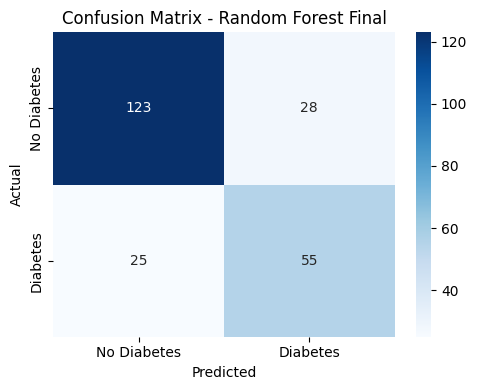

In [489]:
model = RandomForestClassifier(random_state=42, max_depth=11, n_estimators=351)
steps = [
        ('base', BasePreprocessor()),
        #('feature', FeatureEngineering()),
        ('imputer', SimpleImputer(strategy='median')),
        ('log', LogTransform()),
        ('scaler', StandardScaler()),
        ('model', model)
]
pipeline = Pipeline(steps)
results = (run_pipeline(f"RandomForest_final", pipeline))

plot_confusion_matrix(y_test, pipeline.predict(X_test), "Random Forest Final")

In [490]:
df_results = pd.DataFrame([results])
df_results = df_results.sort_values(by="test_f1", ascending=False)
display(df_results)

,method,cv_f1,test_acc,test_f1
0,RandomForest_final,0.6442,0.7706,0.6748
